# Importing the data file

In [23]:
import pandas as pd

news_path = "../data/raw/newsData/raw_analyst_ratings.csv"

df_news = pd.read_csv(news_path)

df_news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# Descriptive Statistics

### Counting articles per publisher

In [24]:
df_news["headline_length"] = df_news["headline"].str.len()
df_news.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87


In [25]:
df_news["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### Visualization of the headline length distribution

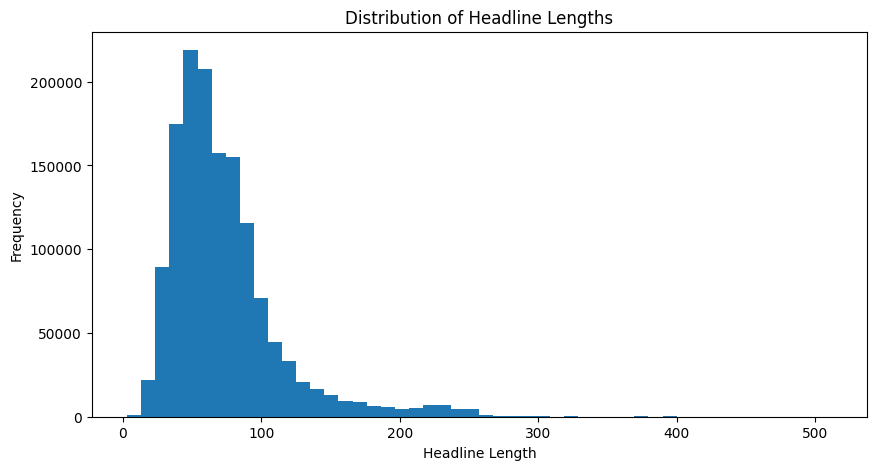

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df_news["headline_length"], bins=50)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most headlines are less than 100 characters in length, with a few having upto 400 characters.

### Analyzing articles per publisher

In [27]:
publisher_counts = df_news["publisher"].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

### Analyzing date trends

In [32]:
df_news["date"] = pd.to_datetime(df_news["date"], format="mixed", utc=True)
df_news["date_only"] = df_news["date"].dt.date
df_news["date"].isna().sum()

np.int64(0)

There are no invalid dates, so no cleaning is required. Although, some rows do not contain a timezone so pandas threw an error. To solve this, all dates were converted to utc time zone.

### Counting frequency of news publication by date

In [ ]:
daily_news_count = df_news.groupby("date_only").size()
daily_news_count.head()

date_only
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64

In [30]:
daily_news_count.sort_values(ascending=False).head(10)

date_only
2020-03-12    2739
2020-02-28    1620
2020-03-19    1595
2020-02-27    1567
2020-03-06    1428
2020-05-07    1398
2020-03-23    1391
2020-04-29    1389
2020-03-11    1384
2020-04-30    1327
dtype: int64

The data shows that there was a significant peak in news publication in 2020-03-12 (March 12, 2020). The number of publications is almost twice as much as that of most days. This could be attributed to the massive acceleration of the COVID-19 pandemic, resulting in a global stock market crash.

### Visualizing frequency of news publications by date

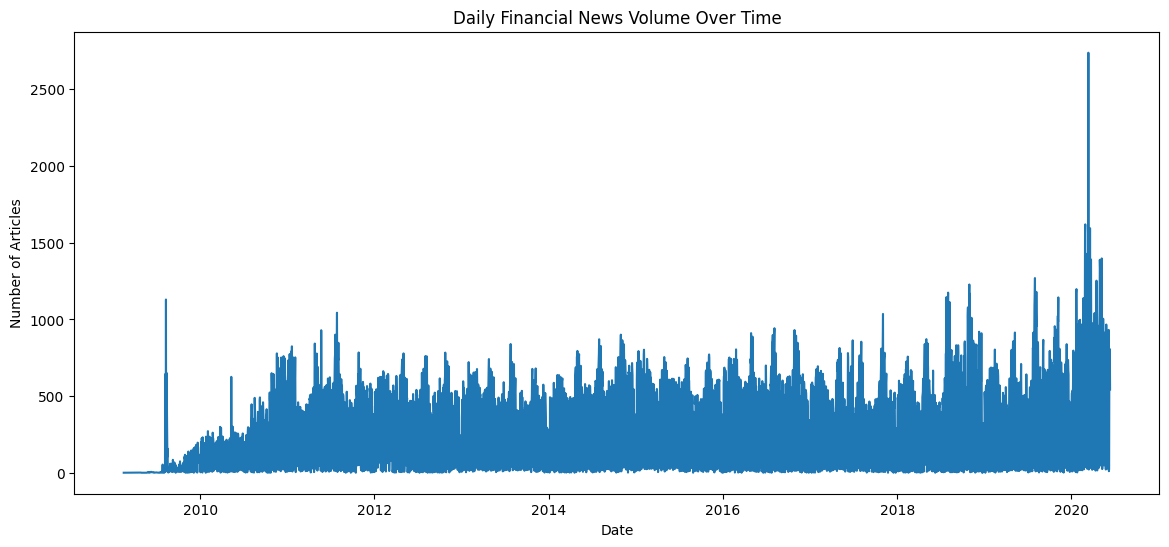

In [ ]:
plt.figure(figsize=(14,6))

daily_news_count.plot()

plt.title("Daily Financial News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

# Text analysis

### Cleaning the headlines (pre-processing)

In [34]:
import re

df_news["clean_headline"] = (
    df_news["headline"]
    .astype(str)
    .str.lower()
    .apply(lambda x: re.sub(r"[^\w\s]", "", x))
)

df_news[["headline", "clean_headline"]].head()

,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks that hit 52week highs on friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks that hit 52week highs on wednesday
2,71 Biggest Movers From Friday,71 biggest movers from friday
3,46 Stocks Moving In Friday's Mid-Day Session,46 stocks moving in fridays midday session
4,B of A Securities Maintains Neutral on Agilent...,b of a securities maintains neutral on agilent...


### Identifying common words in headlines

In [ ]:
from collections import Counter

all_words = " ".join(df_news["clean_headline"]).split()

word_counts = Counter(all_words)

word_counts.most_common(20)


[('to', 402875),
 ('of', 269807),
 ('on', 245071),
 ('for', 238895),
 ('in', 220556),
 ('the', 212758),
 ('vs', 162061),
 ('stocks', 161868),
 ('est', 140578),
 ('eps', 128910),
 ('from', 120708),
 ('shares', 114182),
 ('and', 113434),
 ('reports', 108705),
 ('update', 91680),
 ('market', 90879),
 ('earnings', 87185),
 ('with', 84203),
 ('sales', 79524),
 ('top', 78648)]

### Removing stop words that pollute the result

In [36]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in all_words
    if word not in stop_words
]

filtered_counts = Counter(filtered_words)
filtered_counts.most_common(20)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megde\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


[('vs', 162061),
 ('stocks', 161868),
 ('est', 140578),
 ('eps', 128910),
 ('shares', 114182),
 ('reports', 108705),
 ('update', 91680),
 ('market', 90879),
 ('earnings', 87185),
 ('sales', 79524),
 ('top', 78648),
 ('pt', 73043),
 ('announces', 66528),
 ('price', 64231),
 ('buy', 64059),
 ('downgrades', 61942),
 ('trading', 61156),
 ('benzingas', 57985),
 ('raises', 57798),
 ('upgrades', 56804)]

The data still contains generic terms like 'vs' so filtering using custom stop words is needed.

In [42]:
custom_stopwords = {
    "vs", "est", "pt", "benzingas", "update", 
    "reports", "shares", "stocks", "stock", 
    "market", "top", "trading"
}

all_stopwords = stop_words.union(custom_stopwords)

filtered_words = [
    word for word in all_words
    if word not in all_stopwords and len(word) > 2
]

filtered_counts = Counter(filtered_words)

filtered_counts.most_common(15)

[('eps', 128910),
 ('earnings', 87185),
 ('sales', 79524),
 ('announces', 66528),
 ('price', 64231),
 ('buy', 64059),
 ('downgrades', 61942),
 ('raises', 57798),
 ('upgrades', 56804),
 ('target', 54616),
 ('maintains', 52961),
 ('52week', 49802),
 ('higher', 48163),
 ('new', 48061),
 ('session', 45326)]

### Extracting common financial phrases

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words=list(all_stopwords),
    max_features=30
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df_news["clean_headline"]
)

bigram_counts = bigram_matrix.sum(axis=0).A1

bigram_freq = sorted(
    zip(
        bigram_vectorizer.get_feature_names_out(),
        bigram_counts
    ),
    key=lambda x: x[1],
    reverse=True
)

bigram_freq[:20]

[('price target', np.int64(47266)),
 ('earnings scheduled', np.int64(32056)),
 ('initiates coverage', np.int64(28980)),
 ('adj eps', np.int64(21690)),
 ('premarket session', np.int64(21670)),
 ('q1 eps', np.int64(20704)),
 ('q2 eps', np.int64(20258)),
 ('q3 eps', np.int64(20043)),
 ('hit 52week', np.int64(19962)),
 ('q4 eps', np.int64(19845)),
 ('new 52week', np.int64(19070)),
 ('option alert', np.int64(18226)),
 ('biggest movers', np.int64(17795)),
 ('52week highs', np.int64(16956)),
 ('set new', np.int64(16801)),
 ('morgan stanley', np.int64(15379)),
 ('raises price', np.int64(15352)),
 ('upgrades downgrades', np.int64(14822)),
 ('estimate sales', np.int64(14318)),
 ('52week lows', np.int64(14307))]

### Visualizing top phrases

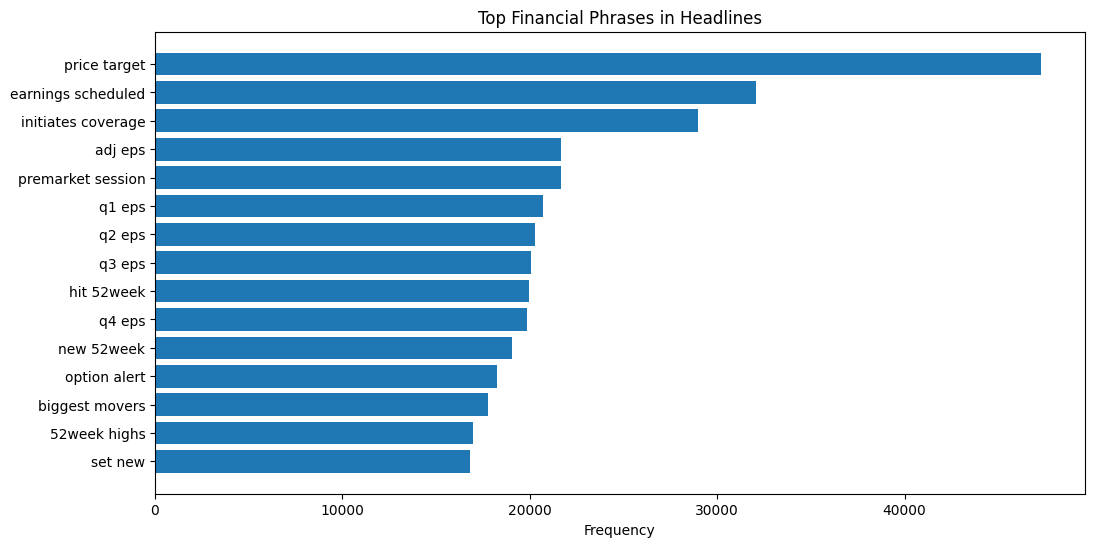

In [45]:
phrases = [x[0] for x in bigram_freq[:15]]
counts = [x[1] for x in bigram_freq[:15]]

plt.figure(figsize=(12,6))

plt.barh(phrases, counts)

plt.title("Top Financial Phrases in Headlines")
plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.show()

The most common phrases in the headlines are related to:

- stock price targets,
- earnings reports,
- analyst upgrades/downgrades,
- and stocks reaching new highs or lows.

This shows that the dataset mainly focuses on company performance and stock market activity.

### TF-IDF Analysis

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words=list(all_stopwords),
    max_features=20
)
tfidf_matrix = tfidf.fit_transform(
    df_news["clean_headline"]
)
tfidf_scores = zip(
    tfidf.get_feature_names_out(),
    tfidf_matrix.sum(axis=0).tolist()[0]
)

sorted_tfidf = sorted(
    tfidf_scores,
    key=lambda x: x[1],
    reverse=True
)

sorted_tfidf


[('eps', 93615.40083270897),
 ('earnings', 81376.77967996657),
 ('sales', 56864.58843078643),
 ('announces', 55981.717187454335),
 ('downgrades', 52648.661776730725),
 ('buy', 44229.096663390075),
 ('upgrades', 44184.551296566344),
 ('52week', 43898.03780227762),
 ('higher', 41251.90340306957),
 ('us', 40937.93396797477),
 ('price', 40333.6756389023),
 ('raises', 39324.16161364343),
 ('new', 38869.408211815324),
 ('says', 38110.340143995134),
 ('maintains', 34194.87368831646),
 ('inc', 32852.32860360393),
 ('session', 32248.56655178607),
 ('target', 32194.556246935623),
 ('moving', 30457.56906000187),
 ('q4', 30439.112804599674)]

### Visualizing TF-IDF results

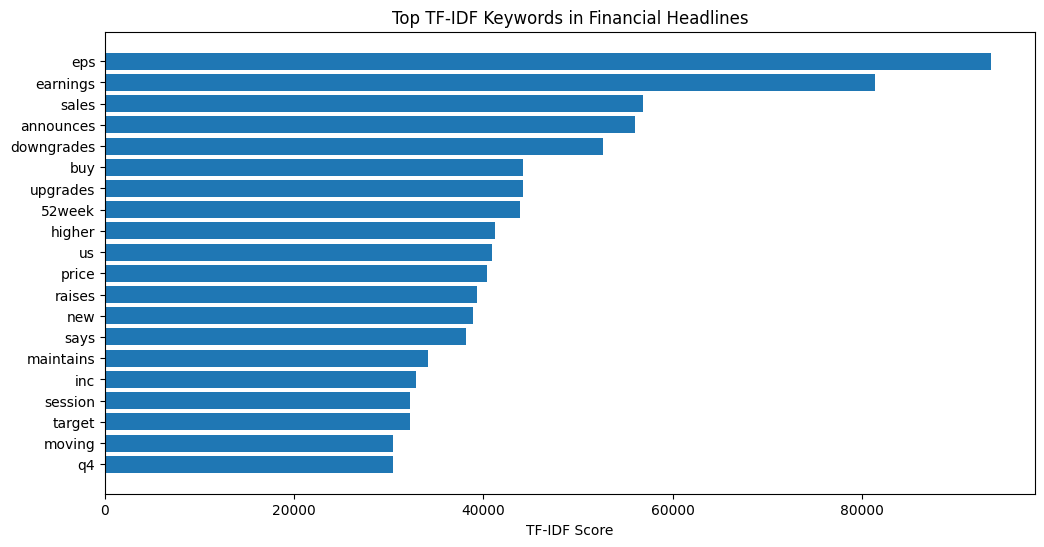

In [48]:
terms = [x[0] for x in sorted_tfidf]
scores = [x[1] for x in sorted_tfidf]

plt.figure(figsize=(12,6))

plt.barh(terms, scores)

plt.title("Top TF-IDF Keywords in Financial Headlines")
plt.xlabel("TF-IDF Score")

plt.gca().invert_yaxis()

plt.show()

TF-IDF analysis highlights the most important and distinctive terms in the headlines. The results further confirm that the dataset strongly focuses on earnings announcements, analyst activity, stock-price movements and corporate financial performance.

## Time series Analysis

In [51]:
df_news["hour"] = df_news["date"].dt.hour

hourly_counts = (
    df_news["hour"]
    .value_counts()
    .sort_index()
)

hourly_counts

hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
Name: count, dtype: int64

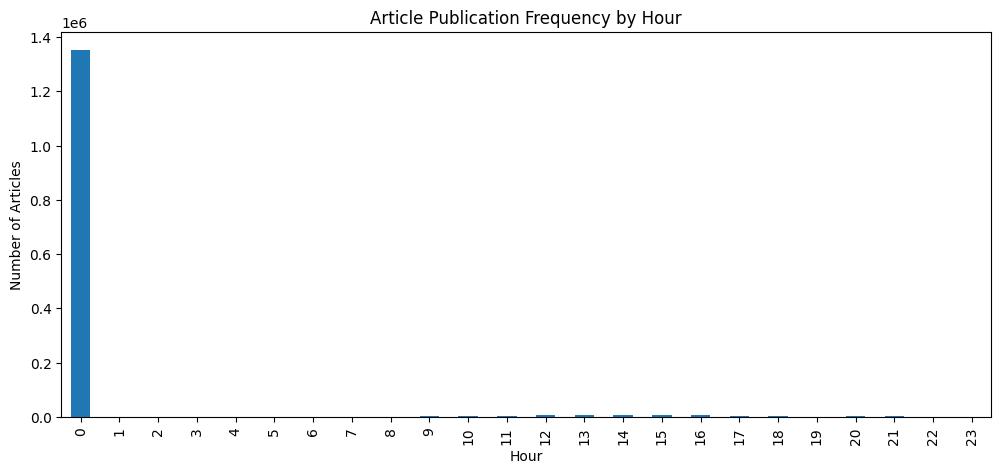

In [52]:
plt.figure(figsize=(12,5))

hourly_counts.plot(kind="bar")

plt.title("Article Publication Frequency by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")

plt.show()

A very large number of articles appear at hour 0 (midnight). This is likely caused by incomplete timestamp information in the dataset, where articles containing only dates were automatically converted to 00:00:00 during preprocessing. As a result, hour level publication analysis may be less reliable than daily trend analysis.

# Publisher analysis

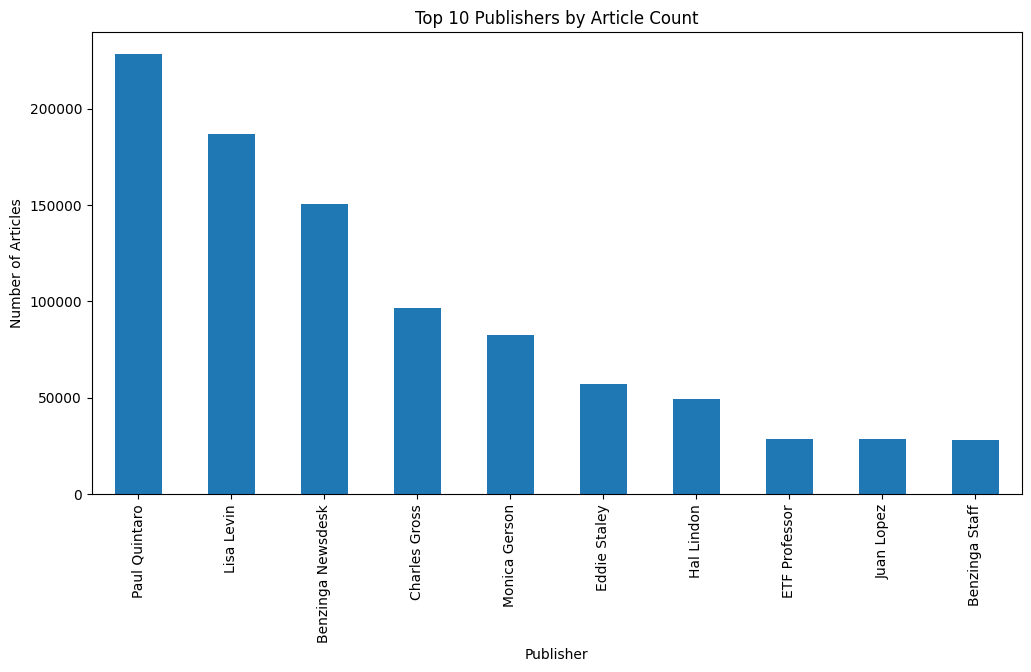

In [53]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))
top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.show()

A small number of publishers contribute a large proportion of the articles in the dataset. This suggests that financial news coverage is concentrated among a few highly active financial news providers.

### Extracting publisher domains

In [54]:
email_publishers = df_news[
    df_news["publisher"].str.contains("@", na=False)
]

email_publishers["publisher"].head()

5     vishwanath@benzinga.com
6     vishwanath@benzinga.com
8     vishwanath@benzinga.com
11    vishwanath@benzinga.com
22    vishwanath@benzinga.com
Name: publisher, dtype: str

In [55]:
email_publishers = email_publishers.copy()

email_publishers["domain"] = (
    email_publishers["publisher"]
    .str.split("@")
    .str[-1]
)

email_publishers["domain"].head()

5     benzinga.com
6     benzinga.com
8     benzinga.com
11    benzinga.com
22    benzinga.com
Name: domain, dtype: object

In [56]:
domain_counts = (
    email_publishers["domain"]
    .value_counts()
)

domain_counts.head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

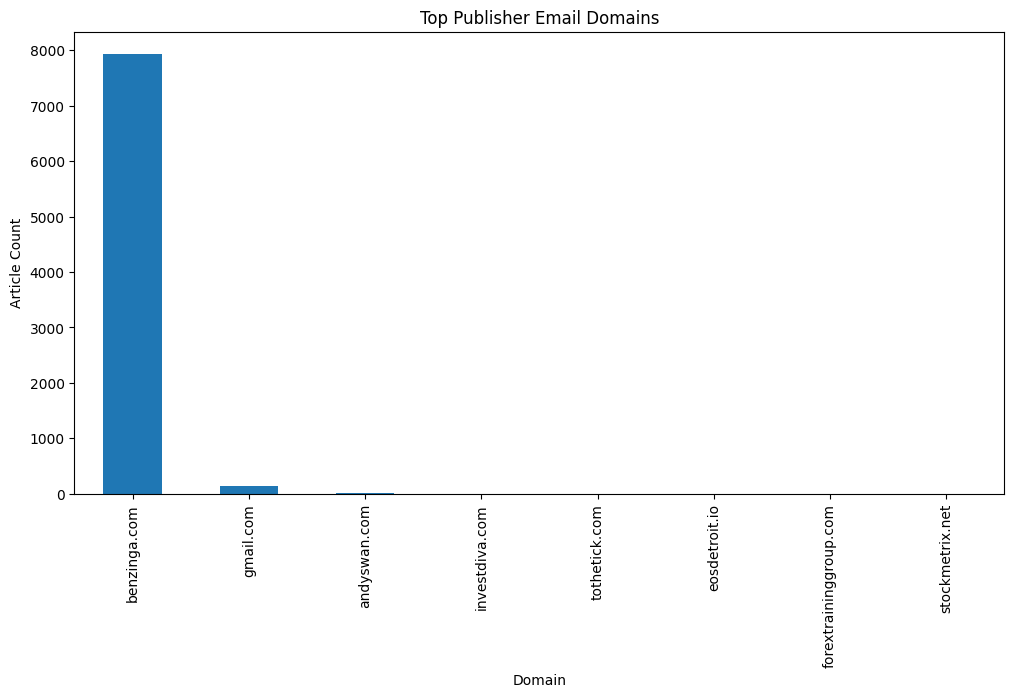

In [57]:
top_domains = domain_counts.head(10)

plt.figure(figsize=(12,6))

top_domains.plot(kind="bar")

plt.title("Top Publisher Email Domains")
plt.xlabel("Domain")
plt.ylabel("Article Count")

plt.show()

Several publisher names appear as email addresses rather than organization names. A significant amount of news are published by one organization (benzinga.com).